
# 🐦 Bengaluru Urban Avian Bio-Acoustic Observatory
## Google Colab: statistical analysis, validation & conservation trends

This notebook is designed for the project's **BirdNET event logs + `detections.csv`**.

### What it does
- Cleans and de-duplicates the exported event table.
- Separates **CONFIRMED / CANDIDATE / LOW_CONFIDENCE / NON_WHITELISTED** events.
- Produces species-frequency graphics, hour-of-day heatmaps, confidence/RMS relationships, event-status graphics, and a detection timeline.
- Parses the long-run text log for **MATCH**, **MATCH-SUPPRESSED**, **MATRIX state**, **telemetry**, and **feature-save** events.
- Creates a **scientifically honest confusion-matrix workflow**: a true confusion matrix is generated only after a `ground_truth_species` label is supplied by manual review.
- Adds a **House Sparrow case study** and an external conservation-trend context section.

> Important: acoustic detection counts are **not population counts**. A short deployment cannot by itself prove population decline. The notebook therefore treats my station data as local acoustic observations and uses independent long-term evidence for population-trend claims.



## 0. Upload the files

Upload:
1. `detections.csv` (for reference, lookup my github repository for 'detections.csv')
2. your long-run log text file

You can repeat the upload cell later with a newer run.


In [1]:

from google.colab import files
uploaded = files.upload()

print("Uploaded:")
for name in uploaded:
    print(" -", name)


Saving detections.csv to detections.csv
Uploaded:
 - detections.csv


In [2]:

# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import re, json, math, os

from scipy import stats
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_fscore_support, accuracy_score
)

# ---- Visual theme: pixel / technical / bio-acoustic ----
BG = "#07111F"        # deep navy
NAVY = "#0B2038"
CYAN = "#20D6D0"
TEAL = "#25A7A0"
LIME = "#C7D95A"
YELLOW = "#F3E55B"
CORAL = "#FF6B6B"
WHITE = "#F4F7F8"
MUTED = "#A8B6C5"
GRID = "#23364A"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "axes.edgecolor": GRID,
    "axes.labelcolor": WHITE,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": WHITE,
    "grid.color": GRID,
    "grid.alpha": 0.45,
    "font.family": "DejaVu Sans",
})



## 1. Load and inspect the station data

The current supplied CSV contains event-level fields such as timestamp, species, confidence, RMS, detection status, whitelist flag, spectrogram path and feature JSON.

Because this export contains exact duplicate rows, the notebook reports both:
- **raw exported rows**
- **unique event rows after exact de-duplication**

This prevents duplicated exports from inflating frequencies.


In [3]:

csv_candidates = [p for p in Path(".").glob("*.csv")]
log_candidates = [p for p in Path(".").glob("*.txt")]

assert csv_candidates, "Upload detections.csv first."
csv_path = csv_candidates[0]
df_raw = pd.read_csv(csv_path)

# Parse time and convert to IST
df = df_raw.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df["timestamp_ist"] = df["timestamp"] + pd.Timedelta(hours=5, minutes=30)
df["date_ist"] = df["timestamp_ist"].dt.date
df["hour_ist"] = df["timestamp_ist"].dt.hour
df["confidence_num"] = pd.to_numeric(df["confidence"], errors="coerce")
df["rms_num"] = pd.to_numeric(df["rms"], errors="coerce")
df["battery_num"] = pd.to_numeric(df["battery"], errors="coerce")

# Exact duplicate removal
df_unique = df.drop_duplicates().copy()

print(f"Raw exported rows   : {len(df_raw):,}")
print(f"Unique rows          : {len(df_unique):,}")
print(f"Exact duplicate rows : {len(df_raw)-len(df_unique):,}")
print()
print("Raw detection_status:")
print(df["detection_status"].value_counts(dropna=False))
print()
print("Unique detection_status:")
print(df_unique["detection_status"].value_counts(dropna=False))


Raw exported rows   : 3,701
Unique rows          : 2,120
Exact duplicate rows : 1,581

Raw detection_status:
detection_status
NON_WHITELISTED     2111
LOW_CONFIDENCE       787
CANDIDATE            615
CONFIRMED            153
NaN                   34
detection_status       1
Name: count, dtype: int64

Unique detection_status:
detection_status
NON_WHITELISTED     1195
LOW_CONFIDENCE       441
CANDIDATE            375
CONFIRMED             91
NaN                   17
detection_status       1
Name: count, dtype: int64


In [4]:

# Useful summary tables
status_summary = (
    df_unique["detection_status"]
    .fillna("UNSPECIFIED")
    .value_counts()
    .rename_axis("status")
    .reset_index(name="events")
)

confirmed = df_unique[df_unique["detection_status"].eq("CONFIRMED")].copy()
candidate = df_unique[df_unique["detection_status"].eq("CANDIDATE")].copy()
low_conf = df_unique[df_unique["detection_status"].eq("LOW_CONFIDENCE")].copy()
non_white = df_unique[df_unique["detection_status"].eq("NON_WHITELISTED")].copy()

print("Confirmed events:", len(confirmed))
print("Confirmed species:", confirmed["species"].nunique())
print("Date range:", df_unique["timestamp_ist"].min(), "to", df_unique["timestamp_ist"].max())

display(
    confirmed["species"].value_counts()
    .rename("confirmed_events")
    .to_frame()
)


Confirmed events: 91
Confirmed species: 9
Date range: 2026-09-11 18:47:29+00:00 to 2026-09-13 19:16:41+00:00


,confirmed_events
species,
Red-whiskered Bulbul,26
House Crow,25
Red-vented Bulbul,16
Common Myna,16
Purple Sunbird,2
Asian Koel,2
Greater Coucal,2
White-throated Kingfisher,1
House Sparrow,1


## 2. Pixel-style status overview

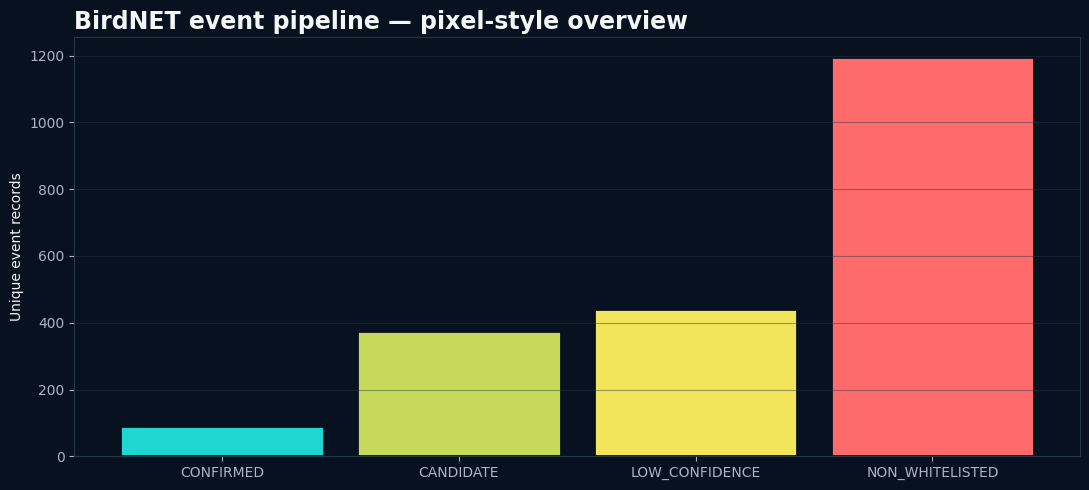

In [5]:

# Block / pixel-style status chart
status_order = ["CONFIRMED", "CANDIDATE", "LOW_CONFIDENCE", "NON_WHITELISTED"]
palette_map = {
    "CONFIRMED": CYAN,
    "CANDIDATE": LIME,
    "LOW_CONFIDENCE": YELLOW,
    "NON_WHITELISTED": CORAL,
}

status_counts = (
    df_unique["detection_status"].fillna("UNSPECIFIED")
    .value_counts()
    .reindex(status_order).fillna(0)
)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(status_counts))
vals = status_counts.values

for i, v in enumerate(vals):
    # blocky bar made of square pixels
    ax.bar(i, v, width=0.86, color=palette_map[status_counts.index[i]], edgecolor=BG, linewidth=2)

ax.set_xticks(x, status_counts.index)
ax.set_ylabel("Unique event records")
ax.set_title("BirdNET event pipeline — pixel-style overview", loc="left", fontsize=17, weight="bold")
ax.grid(axis="y")
plt.tight_layout()
plt.show()


## 3. Confirmed species: frequency + confidence

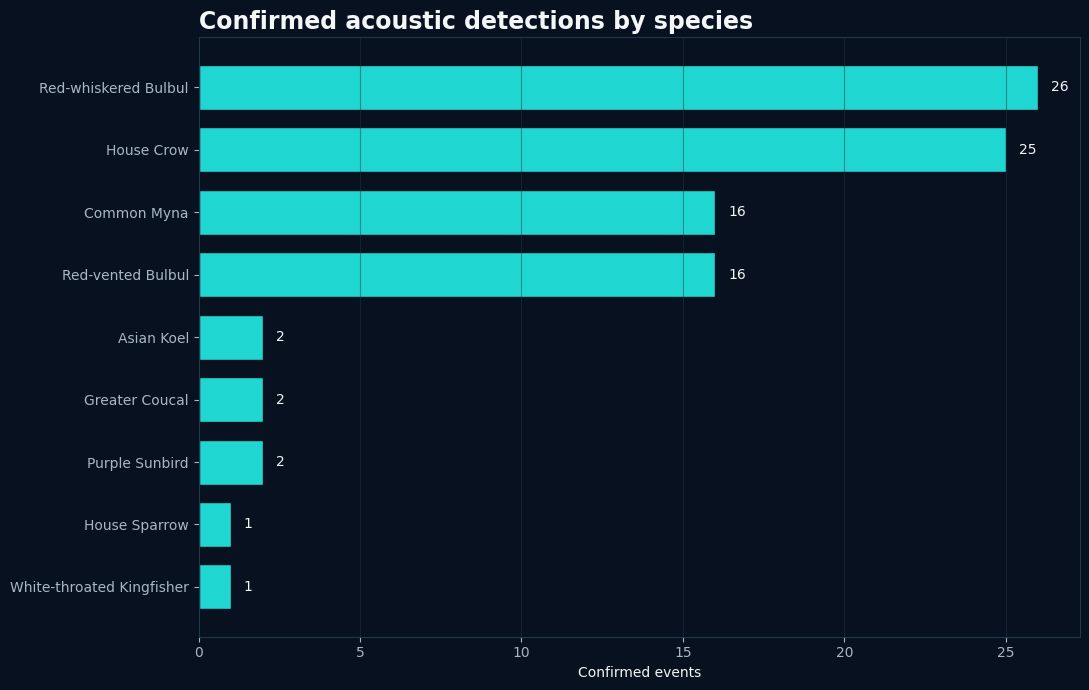

In [6]:

species_counts = (
    confirmed["species"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(species_counts))
ax.barh(y, species_counts.values, color=CYAN, edgecolor=BG, height=0.72)
ax.set_yticks(y, species_counts.index)
ax.set_xlabel("Confirmed events")
ax.set_title("Confirmed acoustic detections by species", loc="left", fontsize=17, weight="bold")
ax.grid(axis="x")

for yi, v in enumerate(species_counts.values):
    ax.text(v + 0.4, yi, str(int(v)), va="center", color=WHITE, fontsize=10)

plt.tight_layout()
plt.show()

# Confidence distribution for confirmed species
top_species = confirmed["species"].value_counts().head(9).index
box = confirmed[confirmed["species"].isin(top_species)].copy()

fig = px.box(
    box,
    x="species",
    y="confidence_num",
    points="all",
    color="species",
    template="plotly_dark",
    title="Confidence distribution of confirmed species",
)
fig.update_layout(
    plot_bgcolor=BG,
    paper_bgcolor=BG,
    font_color=WHITE,
    showlegend=False,
    xaxis_title="Species",
    yaxis_title="BirdNET confidence",
)
fig.update_traces(marker=dict(color=CYAN, size=6), line=dict(color=LIME))
fig.show()


## 4. Pixelated hour-of-day activity heatmap

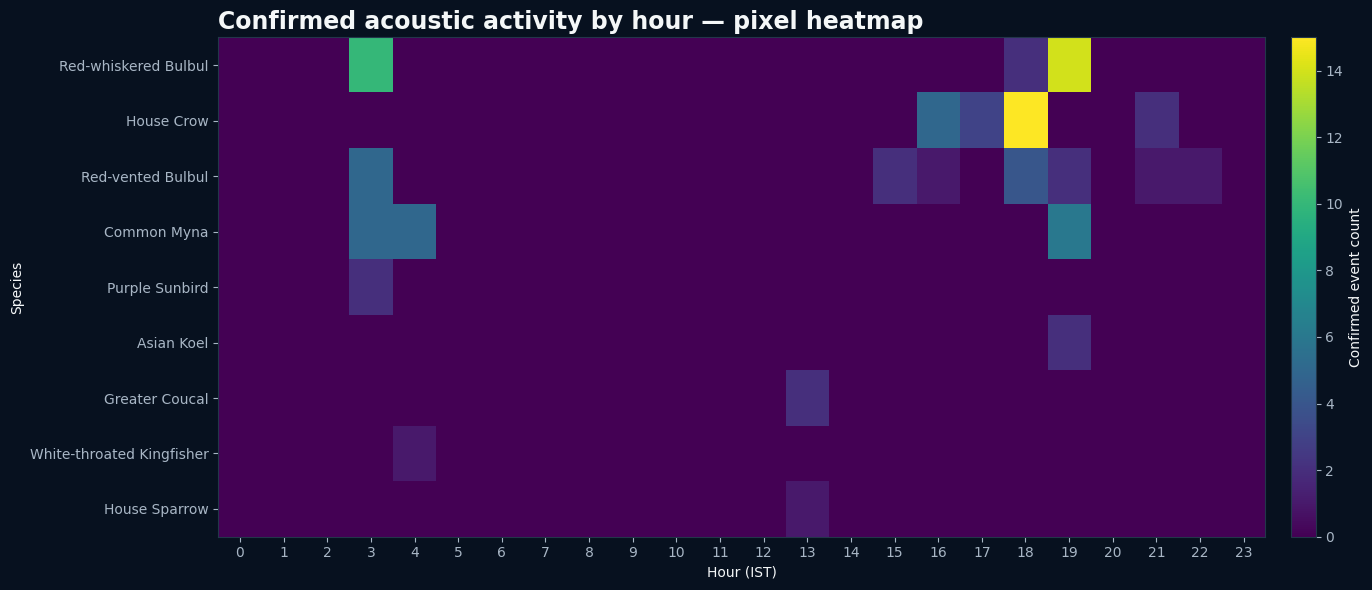

In [7]:

# Confirmed activity by IST hour
heat = (
    confirmed.assign(hour=confirmed["hour_ist"].astype(int))
    .pivot_table(index="species", columns="hour", values="confidence_num", aggfunc="size", fill_value=0)
)

# Keep the most active species for readability
top_for_heat = confirmed["species"].value_counts().head(10).index
heat = heat.reindex(top_for_heat)

# Ensure all hours exist
heat = heat.reindex(columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(
    heat.values,
    aspect="auto",
    interpolation="nearest",   # hard edges = pixel aesthetic
    cmap="viridis"
)
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("Hour (IST)")
ax.set_ylabel("Species")
ax.set_title("Confirmed acoustic activity by hour — pixel heatmap", loc="left", fontsize=17, weight="bold")
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Confirmed event count")
plt.tight_layout()
plt.show()


## 5. Confidence × RMS acoustic-space plot

In [8]:

plot_df = df_unique[df_unique["confidence_num"].notna() & df_unique["rms_num"].notna()].copy()

# Make status order stable
plot_df["status"] = plot_df["detection_status"].fillna("UNSPECIFIED")

fig = px.scatter(
    plot_df.sample(min(2500, len(plot_df)), random_state=42),
    x="rms_num",
    y="confidence_num",
    color="status",
    symbol="status",
    hover_data=["species", "timestamp_ist"],
    template="plotly_dark",
    title="BirdNET confidence vs acoustic RMS",
)
fig.update_layout(plot_bgcolor=BG, paper_bgcolor=BG, font_color=WHITE)
fig.update_traces(marker=dict(size=7, opacity=0.62))
fig.show()



## 6. Threshold / decision analysis

This section shows how the project's low-SNR evidence policy behaves **without pretending that the model's raw confidence is a probability of correctness**.

A useful first view is:
- what confidence levels appear in confirmed vs non-confirmed events
- how event status changes with confidence
- how the accepted events are distributed by RMS


In [11]:
conf_table = (
    df_unique.assign(status=df_unique["detection_status"].fillna("UNSPECIFIED"))
    .groupby("status")["confidence_num"]
    .agg(["count", "median", "mean", "min", "max"])
    .round(4)
    .sort_values("median", ascending=False)
)
display(conf_table)

# Binned confidence profile
b = df_unique[df_unique["confidence_num"].notna()].copy()
b["confidence_pct"] = b["confidence_num"] * 100
b["confidence_bin"] = pd.cut(
    b["confidence_pct"],
    bins=[0, 5, 10, 20, 40, 60, 80, 100],
    include_lowest=True
)
# Convert Interval objects to strings for Plotly compatibility
b["confidence_bin"] = b["confidence_bin"].astype(str)

profile = pd.crosstab(
    b["confidence_bin"],
    b["detection_status"].fillna("UNSPECIFIED"),
    normalize="index"
).fillna(0) * 100

fig = px.bar(
    profile.reset_index().melt(id_vars="confidence_bin"),
    x="confidence_bin",
    y="value",
    color="detection_status",
    barmode="stack",
    template="plotly_dark",
    title="Event-status composition across confidence bands",
)
fig.update_layout(
    plot_bgcolor=BG,
    paper_bgcolor=BG,
    font_color=WHITE,
    yaxis_title="Percent of events in band",
)
fig.show()

,count,median,mean,min,max
status,,,,,
UNSPECIFIED,17,0.7424,0.6898,0.1182,0.9966
CANDIDATE,375,0.7053,0.5941,0.0510,0.9988
CONFIRMED,91,0.6107,0.5887,0.0811,0.9959
NON_WHITELISTED,1195,0.1700,0.3022,0.0500,0.9979
LOW_CONFIDENCE,441,0.0345,0.0339,0.0079,0.0500
detection_status,0,NaN,NaN,NaN,NaN


## 7. Parse the long-running hrs text log

In [17]:

log_candidates = [p for p in Path(".").glob("*.txt")]

log_path = log_candidates[0] if log_candidates else None
assert log_path is not None, "Upload the log TXT file."

lines = Path(log_path).read_text(encoding="utf-8", errors="ignore").splitlines()

# Parse successful matches
match_rows = []
for line in lines:
    m = re.search(
        r"\[MATCH\] (.*?) \(peak=([0-9.]+)%.*?time=([0-9T:+-]+)\)",
        line
    )
    if m:
        match_rows.append({
            "species": m.group(1),
            "peak_pct": float(m.group(2)),
            "timestamp_utc": m.group(3),
        })

log_matches = pd.DataFrame(match_rows)
if not log_matches.empty:
    log_matches["timestamp_utc"] = pd.to_datetime(log_matches["timestamp_utc"], utc=True, errors="coerce")
    log_matches["timestamp_ist"] = log_matches["timestamp_utc"] + pd.Timedelta(hours=5, minutes=30)
    log_matches["hour_ist"] = log_matches["timestamp_ist"].dt.hour

# Parse matrix states
matrix_states = []
for line in lines:
    m = re.search(r"\[MATRIX\] State -> (.+)", line)
    if m:
        matrix_states.append(m.group(1).strip())

print("Log lines:", len(lines))
print("Successful [MATCH] entries:", len(log_matches))
print("MATRIX state counts:", pd.Series(matrix_states).value_counts().to_dict())
print("Telemetry-unavailable lines:", sum("[TELEMETRY] NodeMCU unavailable" in x for x in lines))
print("MATCH-SUPPRESSED lines:", sum("[MATCH-SUPPRESSED]" in x for x in lines))

if not log_matches.empty:
    display(log_matches["species"].value_counts().rename("log_matches").to_frame())


Log lines: 2587
Successful [MATCH] entries: 0
MATRIX state counts: {'candidate': 108, 'listening': 65, 'bird': 31, 'crow': 22}
Telemetry-unavailable lines: 144
MATCH-SUPPRESSED lines: 61



### Why log and CSV match counts may differ

The text log and `detections.csv` are **not necessarily the same slice of time or the same export stage**. The notebook keeps them as separate evidence streams rather than forcing them to match.

That is important for a research presentation: discrepancies are reported, not hidden.


## 8. True confusion matrix — only after manual ground truth

In [19]:

# Create a validation template from a stratified sample of model events.
# Label these manually with ground_truth_species after listening to the audio /
# inspecting your spectrogram evidence.

validation_candidates = df_unique[
    df_unique["detection_status"].isin(["CONFIRMED", "CANDIDATE", "LOW_CONFIDENCE"])
].copy()

# Sample by status and species where possible
validation_sample = (
    validation_candidates
    .groupby("detection_status", group_keys=False)
    .apply(lambda g: g.sample(min(40, len(g)), random_state=42))
    .reset_index(drop=True)
)

validation_template = validation_sample[
    [
        "id", "timestamp", "species", "confidence_num", "rms_num",
        "detection_status", "spectrogram_path"
    ]
].copy()

validation_template["ground_truth_species"] = ""
validation_template["review_notes"] = ""

validation_template.to_csv("validation_template.csv", index=False)

print("Saved validation_template.csv")
display(validation_template.head(20))


Saved validation_template.csv


/tmp/ipykernel_1610/3129342243.py:13: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,id,timestamp,species,confidence_num,rms_num,detection_status,spectrogram_path,ground_truth_species,review_notes
0,770,2026-09-12 13:12:21+00:00,House Crow,0.987677,0.012582,CANDIDATE,NaN,,
1,109,2026-09-11 22:13:23+00:00,Red-whiskered Bulbul,0.493904,0.049534,CANDIDATE,NaN,,
2,84,2026-09-11 22:12:49+00:00,Red-whiskered Bulbul,0.903653,0.012692,CANDIDATE,NaN,,
3,2005,2026-09-13 13:32:34+00:00,Red-whiskered Bulbul,0.503699,0.022480,CANDIDATE,NaN,,
4,153,2026-09-11 22:14:40+00:00,Red-whiskered Bulbul,0.292262,0.011511,CANDIDATE,NaN,,
5,1974,2026-09-13 13:31:52+00:00,Red-whiskered Bulbul,0.994484,0.019295,CANDIDATE,NaN,,
6,196,2026-09-11 22:17:28+00:00,Common Myna,0.160164,0.011019,CANDIDATE,NaN,,
7,627,2026-09-12 11:53:43+00:00,House Crow,0.237175,0.012153,CANDIDATE,NaN,,
8,1960,2026-09-13 13:31:34+00:00,Red-whiskered Bulbul,0.989432,0.015636,CANDIDATE,NaN,,
9,704,2026-09-12 12:32:35+00:00,Red-whiskered Bulbul,0.057112,0.011065,CANDIDATE,NaN,,



### Turning this into a real confusion matrix

After manually reviewing the sampled events:
1. Fill `ground_truth_species`.
2. Upload the completed `validation_template.csv`.
3. Run the next cell.

A confusion matrix requires **true/ground-truth labels**. A plot of model output labels alone is **not** a true confusion matrix.


In [20]:

# Optional: run this after you upload your completed validation CSV.
validation_files = [p for p in Path(".").glob("validation*.csv")]

if len(validation_files) > 1:
    gt = pd.read_csv(validation_files[-1])
    gt = gt[gt["ground_truth_species"].astype(str).str.strip().ne("")].copy()

    if len(gt):
        y_true = gt["ground_truth_species"].astype(str)
        y_pred = gt["species"].astype(str)

        labels = sorted(set(y_true) | set(y_pred))
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        fig = px.imshow(
            cm,
            x=labels,
            y=labels,
            text_auto=True,
            color_continuous_scale=[
                [0, NAVY],
                [0.5, TEAL],
                [1, LIME]
            ],
            template="plotly_dark",
            title="Confusion matrix — manually validated acoustic events"
        )
        fig.update_layout(
            plot_bgcolor=BG,
            paper_bgcolor=BG,
            font_color=WHITE,
            xaxis_title="Predicted species",
            yaxis_title="Ground-truth species",
        )
        fig.show()

        report = classification_report(y_true, y_pred, labels=labels, zero_division=0, output_dict=True)
        report_df = pd.DataFrame(report).T.round(3)
        display(report_df)
    else:
        print("No ground-truth labels filled yet.")
else:
    print("No completed validation file found. Fill validation_template.csv first.")


No completed validation file found. Fill validation_template.csv first.



## 8A. Statistical analysis of the current deployment

The tests below describe **the current event dataset**. They do not estimate city-wide abundance.

Use them to answer narrower questions such as:
- Are confidence distributions different across event classes?
- Is acoustic RMS associated with model confidence?
- Is event activity concentrated in particular hours?

For population-decline research, use the longitudinal design in Section 9B rather than treating these short-run counts as population estimates.


In [21]:

from scipy.stats import kruskal, spearmanr, chi2_contingency

stats_df = df_unique.copy()
stats_df['status'] = stats_df['detection_status'].fillna('UNSPECIFIED')

# 1) Kruskal-Wallis: confidence distributions across event-status groups
conf_groups=[]; group_names=[]
for name, g in stats_df.groupby('status'):
    x=g['confidence_num'].dropna().values
    if len(x)>=2:
        conf_groups.append(x); group_names.append(name)
if len(conf_groups)>=2:
    H,p=kruskal(*conf_groups)
    print(f'Kruskal-Wallis H={H:.3f}, p={p:.4g} across {group_names}')
else:
    print('Not enough groups for Kruskal-Wallis.')

# 2) Spearman: RMS vs confidence
pair=stats_df[['rms_num','confidence_num']].dropna()
if len(pair)>=3:
    rho,p=spearmanr(pair['rms_num'],pair['confidence_num'])
    print(f'Spearman RMS-confidence rho={rho:.3f}, p={p:.4g}, n={len(pair):,}')

# 3) Chi-square: event status vs hour (descriptive association, not causation)
ct=pd.crosstab(stats_df['status'], stats_df['hour_ist'])
if ct.shape[0]>=2 and ct.shape[1]>=2:
    chi2,p,dof,expected=chi2_contingency(ct)
    print(f'Chi-square status x hour: chi2={chi2:.2f}, dof={dof}, p={p:.4g}')


Kruskal-Wallis H=1192.845, p=5.666e-257 across ['CANDIDATE', 'CONFIRMED', 'LOW_CONFIDENCE', 'NON_WHITELISTED', 'UNSPECIFIED']
Spearman RMS-confidence rho=-0.065, p=0.002591, n=2,119
Chi-square status x hour: chi2=534.51, dof=56, p=2.938e-79



## 8B. Statistical view of standardized detection rate

Raw counts are strongly affected by how many hours the station was actually recording. For repeated studies, calculate:

**detection rate = confirmed detections / standardized recording hours**

The cell below supports an optional `effort_hours` table. Add one row per site/date when you have repeated deployments.


In [22]:

# Longitudinal study template — fill this with repeated deployments.
# Required columns: date, site, species, confirmed_events, effort_hours
trend_template = pd.DataFrame({
    'date': pd.to_datetime([]),
    'site': pd.Series(dtype='str'),
    'species': pd.Series(dtype='str'),
    'confirmed_events': pd.Series(dtype='int'),
    'effort_hours': pd.Series(dtype='float'),
})

trend_template['detection_rate_per_hour'] = pd.Series(dtype='float')
trend_template.to_csv('longitudinal_detection_rate_template.csv', index=False)
print('Created longitudinal_detection_rate_template.csv')


Created longitudinal_detection_rate_template.csv


In [23]:

# Optional longitudinal model once the template has real repeated data.
# Poisson GLM with log(effort_hours) as an offset is a starting point for count data.
# For overdispersed counts, compare against a negative-binomial model.
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf

    if Path('longitudinal_detection_rate.csv').exists():
        long_df=pd.read_csv('longitudinal_detection_rate.csv')
        long_df['date']=pd.to_datetime(long_df['date'])
        long_df['time_index']=(long_df['date']-long_df['date'].min()).dt.days/30.4375
        long_df['log_effort']=np.log(long_df['effort_hours'].clip(lower=1e-6))

        # Example model for one species. Change target_species.
        target_species='House Sparrow'
        one=long_df[long_df['species'].eq(target_species)].copy()
        if len(one)>=8:
            model=smf.glm(
                'confirmed_events ~ time_index',
                data=one,
                family=sm.families.Poisson(),
                offset=one['log_effort']
            ).fit()
            print(model.summary())
            print('\nInterpretation: exp(time_index coefficient) is the multiplicative change in expected count per month, conditional on effort.')
        else:
            print('Need at least ~8 repeated observations for this example model; collect more deployments first.')
    else:
        print('Upload longitidunal_detection_rate.csv after filling the repeated-deployment template.')
except Exception as e:
    print('statsmodels section skipped:', e)


Upload longitidunal_detection_rate.csv after filling the repeated-deployment template.



## 9. House Sparrow case study

My current station data contains **House Sparrow events**, but the number of local acoustic detections over a short run should not be interpreted as a population estimate.

The notebook therefore presents:
- the station's House Sparrow detections
- confidence and time-of-day
- comparison with other confirmed species
- an external long-term conservation context

This is the scientifically defensible way to connect my sensor observations to the broader "decline of sparrows in cities".


In [24]:

sparrow = df_unique[df_unique["species"].eq("House Sparrow")].copy()

print("House Sparrow records in this export:", len(sparrow))
display(
    sparrow[
        ["id","timestamp_ist","confidence_num","rms_num","detection_status","battery_num"]
    ].sort_values("timestamp_ist")
)

if len(sparrow):
    fig = px.scatter(
        sparrow,
        x="timestamp_ist",
        y="confidence_num",
        size="rms_num",
        color="detection_status",
        hover_data=["id","rms_num"],
        template="plotly_dark",
        title="House Sparrow acoustic observations in this deployment",
    )
    fig.update_layout(plot_bgcolor=BG, paper_bgcolor=BG, font_color=WHITE)
    fig.show()

    hour_counts = sparrow["hour_ist"].value_counts().sort_index()
    print("House Sparrow hours (IST):", hour_counts.to_dict())


House Sparrow records in this export: 6


,id,timestamp_ist,confidence_num,rms_num,detection_status,battery_num
1518,1519,2026-09-13 13:27:59+00:00,0.036325,0.013210,LOW_CONFIDENCE,100.0
1547,1548,2026-09-13 13:57:17+00:00,0.171834,0.021782,CANDIDATE,100.0
1548,1549,2026-09-13 13:57:18+00:00,0.238323,0.022300,CANDIDATE,100.0
1549,1550,2026-09-13 13:57:19+00:00,0.238323,0.022300,CONFIRMED,100.0
3504,1923,2026-09-13 18:52:03+00:00,0.684781,0.010728,CANDIDATE,100.0
3505,1924,2026-09-13 18:53:06+00:00,0.099951,0.010733,CANDIDATE,100.0


House Sparrow hours (IST): {13.0: 4, 18.0: 2}



### External conservation context for House Sparrow

The **State of India's Birds 2025 update** reports:
- India: long-term trend **-7.16%** (confidence interval -14.03 to 0.48), current annual trend **-2.76%**.
- Karnataka: long-term trend **-47.39%** (CI -60.83 to -30.25), current annual trend **-4.32%** (CI -5.48 to -3.16).

The 2020 State of India's Birds assessment also reported a gradual decline in House Sparrow abundance across the six largest Indian metros, including Bengaluru, even though the national long-term trend was comparatively stable.

These external trends provide context; they are **not estimates computed from my 3-day continuous station deployment**.


In [25]:

# Reproducible external-trend chart (values from published SoIB updates; see notebook citations below)
trend_context = pd.DataFrame({
    "Region": ["India", "Karnataka"],
    "Long-term trend (%)": [-7.16, -47.39],
    "Current annual trend (%)": [-2.76, -4.32],
})

m = trend_context.melt(id_vars="Region", var_name="Metric", value_name="Percent")
fig = px.bar(
    m,
    x="Region",
    y="Percent",
    color="Metric",
    barmode="group",
    template="plotly_dark",
    title="House Sparrow trend context — published SoIB estimates",
)
fig.update_layout(plot_bgcolor=BG, paper_bgcolor=BG, font_color=WHITE, yaxis_title="% change")
fig.show()



## 10. Conservation interpretation

### What this station can show
- Local acoustic presence / absence during sampled periods.
- Relative event activity by hour and day.
- Species composition of detections.
- Confidence / RMS / evidence patterns.
- Changes in acoustic activity across repeated deployments.

### What it cannot show from one short run
- True city-wide population size.
- Long-term population decline from a single deployment.
- Causal effects of tree cutting, pollution or urbanisation without a suitable study design.

### Best research design for a future "decline" study
Repeat the same station protocol across months and seasons, record standardized effort (hours recorded), use fixed sites / habitat strata, manually validate a subset of detections, and model **detection rate or occupancy over time** while accounting for effort and site differences.


## 11. Export figures + summary tables

In [26]:

# Create an output folder for report-ready files
from pathlib import Path
export_dir = Path("analysis_outputs")
export_dir.mkdir(exist_ok=True)

# Summary exports
status_summary.to_csv(export_dir / "status_summary.csv", index=False)
confirmed["species"].value_counts().rename("confirmed_events").to_csv(
    export_dir / "confirmed_species_counts.csv"
)
conf_table.to_csv(export_dir / "confidence_by_status.csv")

print("Saved CSV summaries to", export_dir.resolve())


Saved CSV summaries to /content/analysis_outputs



## 11A. Evidence discipline


> **Local acoustic observation is evidence of local presence/activity, not a direct population census.**

A House Sparrow detection in the present run is therefore a local observation. A claim about population decline must come from repeated standardized acoustic surveys and/or independent long-term population studies. The strongest future design is to combine both.
